# Getting started with GRASS for Conda

Brendan Harmon  
2026-07-03

This is a very short introduction to installing GRASS distributed via
[Conda](https://grass.osgeo.org/download/conda/). With the Conda
distribution of GRASS, you can install GRASS and the rest of the Python
stack for data science with a single command. This means that you can
easily integrate GRASS into data science workflows using the Python
scientific ecosystem. This brief tutorial covers:

- Installing the Conda package and environment manager
- Creating a GRASS environment with Conda
- Running GRASS in a Jupyter notebook

## Manager

Conda is an open source package and environment manager. Many open
source projects use Conda to publish their software. With Conda, you can
easily install collections of these packages in isolated environments to
avoid conflicting software dependencies. With Conda, packages are
distributed via channels, remote repositories that host packages. GRASS
is distributed via conda-forge, a community smithy and repository
(<span class="nocase">conda-forge community</span> 2015). There are
several different distributions of Conda. For this tutorial, install
[Miniforge](https://conda-forge.org/download/), a minimal distribution
of Conda that uses conda-forge as its default channel
(<span class="nocase">conda-forge community</span> 2026). We recommend
Miniforge because it is the easiest, cleanest way to install the GRASS
Conda Package. Other distributions may be incompatible with conda-forge,
requiring proper
[configuration](https://conda-forge.org/docs/user/transitioning_from_defaults/)
to work.

> **Unix**
>
> On Unix-like platforms - including Linux, MacOS, and Windows Subsystem
> for Linux -  
> download the installation shell script and then run it in a terminal:
>
> ``` {bash}
> bash Miniforge3-$(uname)-$(uname -m).sh
> ```

> **Windows**
>
> For Windows, download and run the binary installer. See
> [here](https://github.com/conda-forge/miniforge#install) for more
> detailed instructions.

## Environment

Now that Conda is installed, let’s use it to create an environment for
GRASS. We will install the GRASS, Jupyter Lab, and requests Python
packages with all of their dependencies into this environment. In a
terminal, run [conda
create](https://docs.conda.io/projects/conda/en/stable/commands/create.html)
to create an environment named `grass`. Then use [conda
install](https://docs.conda.io/projects/conda/en/stable/commands/install.html)
to install the GRASS package. Next, run [conda
activate](https://docs.conda.io/projects/conda/en/stable/commands/activate.html)
to start the environment.

``` {bash}
conda create --name grass
conda activate grass
conda install grass jupyterlab requests folium ipyleaflet
```

You can do this with just one line of code:

``` {bash}
conda create -n grass grass jupyterlab requests folium ipyleaflet && conda activate grass
```

If you use a Conda distribution other than Miniforge, you will need to
specify the conda-forge channel when creating the environment with
`-c conda-forge`. You may also need to override your default channel
settings with `--override-channels` to prevent conflicts.

## Notebook

Let’s try the newly installed GRASS Conda package in a Jupyter notebook.
We will use scripting to display maps from a sample dataset. We will
download the dataset, start a GRASS session, and then display raster and
vector maps from the dataset. Let’s begin by launching Jupyter Lab from
the terminal. This will open a new Jupyter notebook in a web browser
window.

``` {bash}
jupyter lab
```

### Start GRASS

To start a GRASS session, we need to define a project and its coordinate
reference system. For this demonstration, we will use the Natural Earth
Dataset for GRASS (Harmon and Breugel 2020). This dataset is a GRASS
project with a collection of global raster and vector data in the World
Geodetic System 1984. In your Jupyter notebook, use Python to download
and unarchive the dataset. Then start a GRASS session using the dataset
as a project. Read more about
[projects](https://grass.osgeo.org/grass-stable/manuals/grass_projects.html)
in GRASS here. Since the dataset is approximately 120MB, it may take a
couple of minutes to download. As a test that GRASS started correctly,
run [g.proj](https://grass.osgeo.org/grass-stable/manuals/g.proj.html)
with flag `g` to print the current projection.

In [1]:
# Import libraries
import os
import sys
import subprocess
from pathlib import Path
import requests
from zipfile import ZipFile

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import GRASS packages
import grass.jupyter as gj
from grass.tools import Tools

# Download dataset
url = "https://zenodo.org/records/13370131/files/natural_earth_dataset.zip?download=1"
filepath = Path.cwd() / "natural_earth_dataset.zip"
request = requests.get(url, allow_redirects=True)
if request.status_code != 200:
    raise ConnectionError(f"Error downloading file: {request.status_code}")
filepath.write_bytes(request.content)

# Unarchive dataset
with ZipFile(filepath, 'r') as archive:
    archive.extractall()

# Delete archive
os.remove(filepath)

# Start GRASS in project
home = Path.cwd()
project = "natural_earth_dataset"
session = gj.init(home, project)
tools = Tools()

# Print projection information
tools.g_proj(format="shell", flags="p")

### Display Raster Map

The Natural Earth raster is a global basemap with land cover and shaded
relief rendered with a natural color scheme. Display the Natural Earth
raster map with
[d.rast](https://grass.osgeo.org/grass-stable/manuals/d.rast.html).

In [2]:
# Display natural earth raster
m = gj.Map(width=800)
m.d_rast(map="natural_earth")
m.show()

<figure>
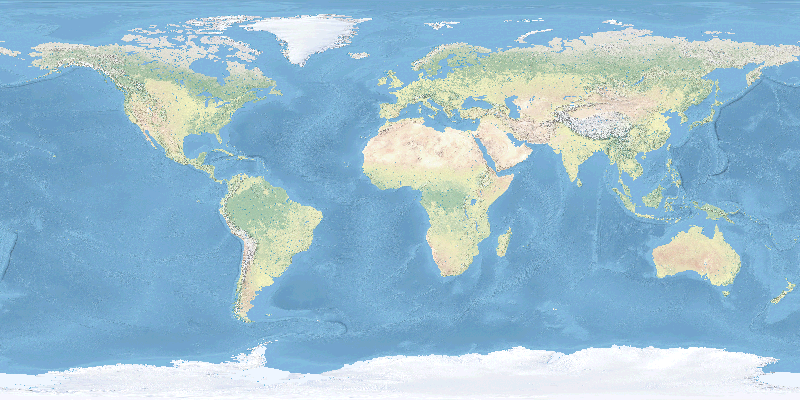
<figcaption aria-hidden="true">Natural Earth</figcaption>
</figure>

### Display Vector Map

Now display a vector map of global rivers. First apply a thematic color
gradient to the rivers based on their stream order with
[v.colors](https://grass.osgeo.org/grass-stable/manuals/v.colors.html).
Then display the map with
[d.vect](https://grass.osgeo.org/grass-stable/manuals/d.vect.html),
scaling the line width by stream order.

In [3]:
# Display rivers
m = gj.Map(width=800)
tools.v_colors(map="rivers", use="attr", column="scalerank", color="water")
m.d_vect(map="rivers", width_column="strokeweig", width_scale=2)
m.show()

<figure>
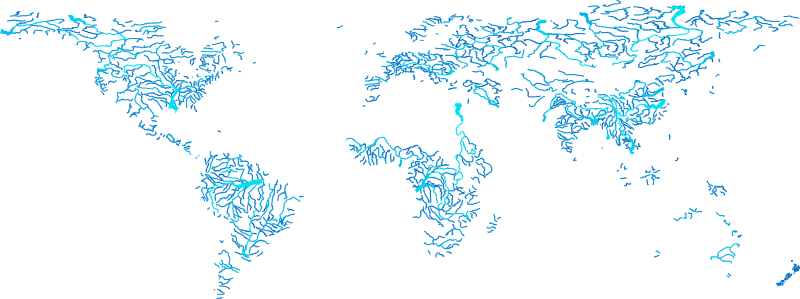
<figcaption aria-hidden="true">Rivers</figcaption>
</figure>

## Reproducibility

Conda environments can also be created from an environment definition
file that specifies the environment name, channel, and packages. This is
an easy way to share and reproduce your environment. While you can
specify versions for given packages, this example just installs the
latest compatible versions for simplicity’s sake. To do this, first use
a text editor to create a YAML file named `environment.yml` with the
following contents:

``` yaml
# environment.yml
name: grass
channels:
  - conda-forge
dependencies:
  - grass
  - jupyterlab
  - requests
```

Then run [conda env
create](https://docs.conda.io/projects/conda/en/stable/commands/env/create.html)
using `--file` to specify your path to the environment definition file:

``` bash
conda env create --file environment.yml
```

<span class="nocase">conda-forge community</span>. 2015.
*<span class="nocase">The conda-forge Project:</span> Community-Based
Software Distribution Built on the Conda Package Format and Ecosystem*.
Zenodo. <https://doi.org/10.5281/zenodo.4774217>.

<span class="nocase">conda-forge community</span>. 2026. *Miniforge*. V.
26.3.2-0. Released. <https://conda-forge.org/download/>.

Harmon, Brendan, and Paulo van Breugel. 2020. “Natural Earth Dataset for
GRASS GIS.” Version 2.0.0. Zenodo.
<https://doi.org/10.5281/zenodo.3762773>.